# Experiment 4: Tree-based Models and Ensemble Learning

**Date:** Dec 2025

## Description

In this experiment, you will explore the Decision Tree algorithm and two powerful ensemble methods: Random Forest and Gradient Boosting. We will focus on:

1. Interpreting models using Feature Importance in Random Forests.
2. Understanding the impact of Learning Rate in Gradient Boosting.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
from sklearn.exceptions import DataConversionWarning

# Suppress warnings
warnings.filterwarnings("ignore")

### Data Loading

We will use a Customer Churn Dataset. The goal is to predict whether a customer will leave the service (Churn=1) or stay (Churn=0) based on various features like account length, plan details, and usage patterns.

The dataset is stored in `Churn_train.csv` and `Churn_test.csv`.

In [2]:
# Load the data
train_data = pd.read_csv('Churn_train.csv')
test_data = pd.read_csv('Churn_test.csv')

########## Start of Your Code ##########
X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values

X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

########## End of Your Code ##########

# check the shapes of the datasets
print(X_train.shape) # (9600, 30)
print(X_test.shape)  # (2400, 30)

(9600, 30)
(2400, 30)


## Task 1: Decision Tree
Decision Trees are prone to overfitting if allowed to grow deep. An overfitted tree learns the training noise rather than the underlying pattern, leading to high training accuracy but poor test accuracy.

In this task, you will train two Decision Trees:
1. Unconstrained Tree: `max_depth = None`
2. Regularized Tree: `max_depth = 8`

Compare their performance on both Training and Test sets.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

########## Start of Your Code ##########

# 1. Initialize and fit the Unconstrained Tree (max_depth=None)
dt_full = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_full.fit(X_train, y_train)

# 2. Initialize and fit the Regularized Tree (max_depth=8)
dt_reg = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_reg.fit(X_train, y_train)

# 3. Calculate accuracies
# Train Accuracy
acc_train_full = accuracy_score(y_train, dt_full.predict(X_train))
acc_train_reg = accuracy_score(y_train, dt_reg.predict(X_train))

# Test Accuracy
acc_test_full = accuracy_score(y_test, dt_full.predict(X_test))
acc_test_reg = accuracy_score(y_test, dt_reg.predict(X_test))

########## End of Your Code ##########

print(f"Unconstrained Tree - Train Acc: {acc_train_full:.4f}, Test Acc: {acc_test_full:.4f}")
print(f"Regularized Tree   - Train Acc: {acc_train_reg:.4f}, Test Acc: {acc_test_reg:.4f}")


Unconstrained Tree - Train Acc: 1.0000, Test Acc: 0.7458
Regularized Tree   - Train Acc: 0.8432, Test Acc: 0.7958


**Question:** Observe the difference between Train and Test accuracy for the Unconstrained Tree. What does this gap indicate? Does restricting the depth help reduce this gap?

## Task 2: Random Forest & Feature Importance

Random Forest improves upon Decision Trees by using Bagging (Bootstrap Aggregating) and feature randomization. Apart from better accuracy, Random Forest provides a way to measure the importance of each feature in the prediction.

In this task, you will:
1. Train a Random Forest Classifier.
2. Extract and visualize the **Feature Importance**.

In [4]:
from sklearn.ensemble import RandomForestClassifier

########## Start of Your Code ##########
# Fit a Random Forest with 100 estimators and random_state=42
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
########## End of Your Code ##########
# Predict on test set and print accuracy
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Random Forest Accuracy: 0.8696


### Visualizing Feature Importance
Tree-based models calculate how much each feature contributes to decreasing the impurity (e.g., Gini impurity). We can visualize this to understand the key drivers of Customer Churn.

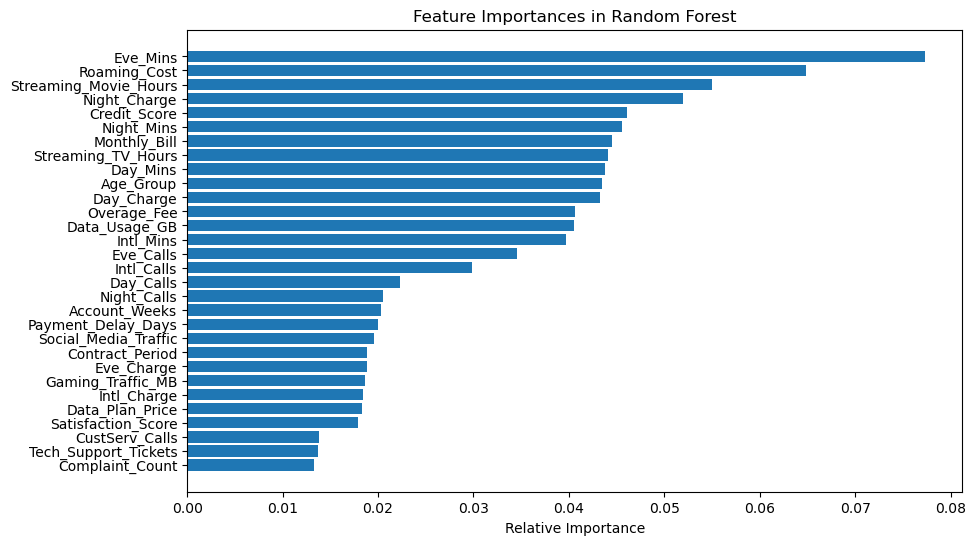

In [5]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = train_data.columns[:-1]

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plotting
plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Random Forest")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

**Observation:** Based on the plot above, which 3 features are the most critical in predicting customer churn?

## Task 3: Gradient Boosting

Gradient Boosting builds trees sequentially. Each new tree tries to correct the errors (residuals) made by the previous trees. 

A crucial hyperparameter in Gradient Boosting is the **Learning Rate**. It controls how much each tree contributes to the final prediction. A lower learning rate usually requires more trees (estimators) to build a complex model, but it is often more robust to overfitting.

In this task, you will explore how the `learning_rate` affects the Test Accuracy.

In [6]:
from sklearn.ensemble import GradientBoostingClassifier

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
accuracy_results = []

########## Start of Your Code ##########

for lr in learning_rates:
    # Initialize GBDT with n_estimators=100, max_depth=3, and current learning_rate
    gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=lr, random_state=42)
    
    # Fit the model
    gb_clf.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    pred = gb_clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    accuracy_results.append(acc)

########## End of Your Code ##########

for lr, acc in zip(learning_rates, accuracy_results):
    print(f"Learning Rate: {lr} -> Test Accuracy: {acc:.4f}")

Learning Rate: 0.01 -> Test Accuracy: 0.7467
Learning Rate: 0.05 -> Test Accuracy: 0.8229
Learning Rate: 0.1 -> Test Accuracy: 0.8417
Learning Rate: 0.5 -> Test Accuracy: 0.8546
Learning Rate: 1.0 -> Test Accuracy: 0.8167


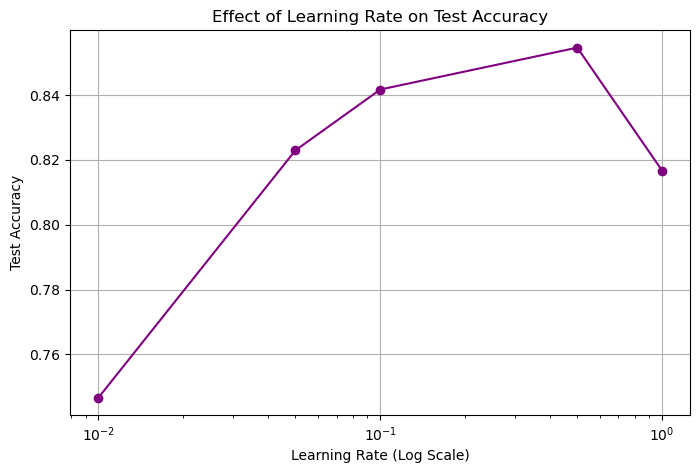

In [7]:
# Plot the relationship between Learning Rate and Accuracy
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, accuracy_results, marker='o', linestyle='-', color='purple')
plt.xscale('log')  # Use log scale for better visualization of small rates
plt.title("Effect of Learning Rate on Test Accuracy")
plt.xlabel("Learning Rate (Log Scale)")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

**Question:** What happens when the Learning Rate is too large (e.g., 1.0)? What happens when it is very small (e.g., 0.01) given the fixed number of estimators (100)?